In [209]:
import numpy as np
import scipy as sp
from scipy import constants as cte
import matplotlib as mpl
import matplotlib.pyplot as plt

\begin{equation}
E^2(z)=\Omega_m(1+z)^3+\Omega_k(1+z)^2+\Omega_\Lambda,\space\space\Omega_k=1-\Omega_m-\Omega_\Lambda
\end{equation}

In [210]:
def cosmologicalExpansion(z, omega_m, omega_lambda, omega_r=0):
    omega_k = 1 - omega_m - omega_lambda - omega_r
    E2 = omega_r*(1+z)**4 + omega_m*(1+z)**3 + omega_k*(1+z)**2 + omega_lambda
    
    if np.sum(E2 < 0) > 0: return -np.ones(np.shape(z)) # Escape value -1 para universo não físico
    else:                  return np.sqrt(E2)    

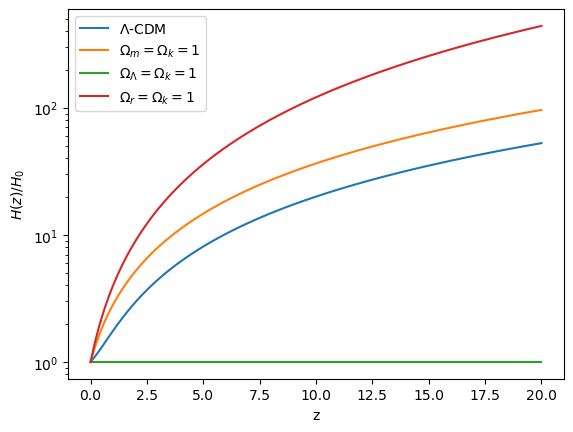

In [211]:
z = np.linspace(0,20,100)
plt.plot(z, cosmologicalExpansion(z, 0.3, 0.7),        label=r"$\Lambda$-CDM")
plt.plot(z, cosmologicalExpansion(z, 1, 0),            label="$\Omega_m=\Omega_k=1$")
plt.plot(z, cosmologicalExpansion(z, 0, 1),            label="$\Omega_\Lambda=\Omega_k=1$")
plt.plot(z, cosmologicalExpansion(z, 0, 0, omega_r=1), label="$\Omega_r=\Omega_k=1$")
plt.xlabel("z")
plt.ylabel("$H(z)/H_0$")
plt.yscale("log")
plt.legend()
plt.show()
plt.close()

In [227]:
# H0 em km/s/Mpc, output em Mpc
# return DH, DC, DM, DA, DL
def cosmologicalDistances(z, H0, omega_m, omega_lambda, omega_r=0):
    DH = 1e-3*cte.c / H0 * np.ones(np.shape(z))
    integDC = lambda z_: 1. / cosmologicalExpansion(z_, omega_m, omega_lambda, omega_r=omega_r)
    omega_k = 1 - omega_m - omega_lambda - omega_r

    if   omega_k > 0:
        Sk = lambda DC: DH * np.sin(DC/DH * np.sqrt(omega_k)) / np.sqrt(omega_k)
    elif omega_k == 0:
        Sk = lambda DC: DC
    elif omega_k < 0:
        Sk = lambda DC: DH * np.sinh(DC/DH * np.sqrt(-omega_k)) / np.sqrt(-omega_k)

    # Cálculo único de z individual
    if np.prod(np.shape(z)) == 1:
        if integDC(0) <= 0 or integDC(z) <= 0:
            print(f"WARNING: Cosmological values 'omega_m' = {omega_m}, 'omega_lambda' = {omega_lambda} are not physical.")
            return 0, 0, 0, 0
        DC = sp.integrate.quad(integDC, 0, z)[0]

    # Cálculo em vetor z
    else:
        DC = np.zeros(np.shape(z))
        if integDC(0) <= 0: # Distância é bem definida em z=0
            print(f"WARNING: Cosmological values 'omega_m' = {omega_m}, 'omega_lambda' = {omega_lambda} are not physical.")
            return DC, DC, DC, DC
        
        for i, zi in enumerate(z):
            if integDC(zi) <= 0: # Distância é bem definido em cada zi
                print(f"WARNING: Cosmological values 'omega_m' = {omega_m}, 'omega_lambda' = {omega_lambda} are not physical.")
                return np.zeros(np.shape(z)), np.zeros(np.shape(z)), np.zeros(np.shape(z)), np.zeros(np.shape(z))
            DC[i] = sp.integrate.quad(integDC, 0, zi)[0]
            
    DM = Sk(DC)
    return DC, DM, DM/(1+z), DM*(1+z)

In [253]:
def cosmologicalTime(z, H0, omega_m, omega_lambda, omega_r=0):
    H0_Hz = H0 / (1e+3 * cte.parsec)
    integT = lambda z_: 1. / (1e+9*cte.year * H0_Hz*(1+z_)*cosmologicalExpansion(z_, omega_m, omega_lambda, omega_r=omega_r))
    integEta = lambda z_: 1. / (1e+9*cte.year * H0_Hz*cosmologicalExpansion(z_, omega_m, omega_lambda, omega_r=omega_r))
    
    if np.prod(np.shape(z)) == 1:
        if integT(0) <= 0 or integT(z) <= 0:
            print(f"WARNING: Cosmological values 'omega_m' = {omega_m}, 'omega_lambda' = {omega_lambda} are not physical.")
            return 0
        t = sp.integrate.quad(integT, 0, z)[0]
        eta = sp.integrate.quad(integEta, z, np.inf)[0]
        
    else:
        t = np.zeros(np.shape(z))
        eta = np.zeros(np.shape(z))
        if integT(0) <= 0: # Distância é bem definida em z=0
            print(f"WARNING: Cosmological values 'omega_m' = {omega_m}, 'omega_lambda' = {omega_lambda} are not physical.")
            return t
        for i, zi in enumerate(z):
            if integT(zi) <= 0: # Distância é bem definido em cada zi
                print(f"WARNING: Cosmological values 'omega_m' = {omega_m}, 'omega_lambda' = {omega_lambda} are not physical.")
                return np.zeros(np.shape(z))
            t[i] = sp.integrate.quad(integT, 0, zi)[0]
            eta[i] = sp.integrate.quad(integEta, zi, np.inf)[0]
    return t, eta

In [256]:
def FLRW(z, H0, omega_m, omega_lambda, omega_r=0):
    E = cosmologicalExpansion(z, omega_m, omega_lambda, omega_r=omega_r)
    H = E * H0
    t, eta = cosmologicalTime(z, H0, omega_m, omega_lambda, omega_r=omega_r)
    chi, DM, DA, DL = cosmologicalDistances(z, H0, omega_m, omega_lambda, omega_r=0)
    mu = 5*np.log10(1e+3*DL)+25
    dV = 1e-3*ct.c * DM**2 / H

    return E, H, t, eta, chi, DM, DA, DL, mu, dV

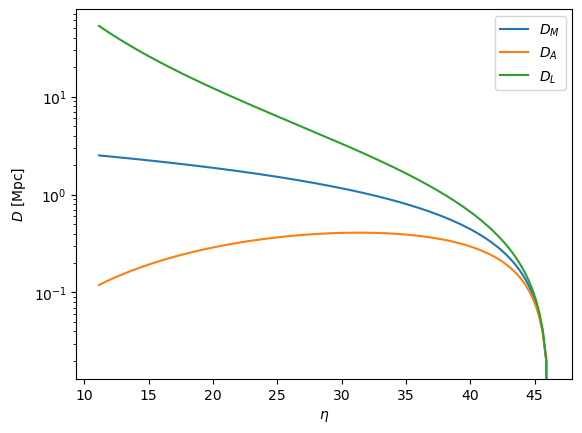

In [261]:
z = np.linspace(20,0,1000)
dist = cosmologicalDistances(z, 70, 0.3, 0.7)
t, eta = cosmologicalTime(z, 70, 0.3, 0.7)

plt.plot(eta, dist[1], label="$D_M$")
plt.plot(eta, dist[2], label="$D_A$")
plt.plot(eta, dist[3], label="$D_L$")

plt.xlabel("$\eta$")
plt.ylabel("$D$ [Mpc]")
plt.yscale("log")
plt.legend()
plt.show()
plt.close()